
# Introduction

This documentation outlines the method for calculating spatially
standardized latitudinal extinction gradients across stage boundaries
using fossil occurrence data from the Paleobiology Database (PBDB) used in Prow-Fleischer et al (in prep).
Consideration is made for cleaning and filtering data and documenting
each step per [Ten simple rules to follow when cleaning occurrence data
in
palaeobiology](https://tenrules.palaeoverse.org/)[@jonesTenSimpleRules2025].


# Setup

In [63]:
rpkg <- c(
  # Data manipulation
  "dplyr", "readr", "tidyr", "purrr", "conflicted",# "tibble",  "forcats", 
  
  # Geospatial data manipulation

  # "terra", "rgplates", "icosa", "chronosphere", "via", "ncdf4",
  
  # # Accessing and cleaning paleontological occurrence data
  "CoordinateCleaner", "fossilbrush", "divvy",# "divDyn", "paleobioDB", "CoordinateCleaner", "fossilbrush", "divvy",
  
  # # Plotting and visualization
   "ggplot2", "RColorBrewer", "DT", "patchwork")# "ggpubr", "patchwork", "ggstance", "RColorBrewer", "DT","viridis","cowplot","grid",
  
  # # Sharing and publishing
  # "piggyback", "downloadthis")

lapply(rpkg, function(pkg) {
  tryCatch(
    library(pkg, character.only = TRUE)
  )
})|>invisible()


conflicted::conflict_prefer(name = "filter", winner = "dplyr",losers = "stats")

# color blind friendly palette: okabe ito
okabe_ito_10 <- c(
  "#E69F00", # orange
  "#56B4E9", # sky blue
  "#009E73", # bluish green
  "#F0E442", # yellow
  "#0072B2", # blue
  "#D55E00", # vermillion
  "#CC79A7", # reddish purple
  "#999999", # grey
  "#E1BE6A", # tan
  "#40B0A6"  # teal
)



[conflicted] Removing existing preference.
[conflicted] Will prefer dplyr::filter over stats::filter.



## Custom Functions

Latitudinally bin occurrence data

In [35]:
#df is cleaned occurence dataframe, lower is list of lower latitude boundaries, 
#upper is the upper boundaries and mid are mid points for plotting purposes. T
#his function makes a copy of original df and adds the latbin column so if you are only wanting 
#to plot latitudinal distributions of taxa you can assign the midpoint lat it will plot data against (See Other Data Exploration section)

#use with divvy::bandit latitudinal subsampling
filter_bin <- function(df, lower, upper, mid) { 
  df %>%
    filter(paleolat >= lower, paleolat < upper) %>%
    mutate(latbin = mid) %>%
    distinct(accepted_name, .keep_all = TRUE)}


# use fitler_bin_hexa recommended only for some subsampling rountine like divvy:cookies
filter_bin_hexa <- function(df, lower, upper, mid) { 
  df %>%
    filter(hexa_lat >= lower, hexa_lat < upper) %>%
    mutate(latbin = mid) %>%
    distinct(accepted_name, .keep_all = TRUE)}

Function to calculate the percentage of genera per latitude bin that went extinct at the end of a given stage.

In [36]:
calc_extinction <- function(fossils, age) {
  
  total_genera <- fossils %>%
    filter(early_interval == age) %>%
    group_by(latbin) %>%
    summarize(num_genera = n_distinct(accepted_name), .groups = "drop")
  
  # Count extinct genera by exact paleolatitude
  num_extinct <- fossils %>%
    filter(early_interval == age, ex == 1) %>% # this line selects genera that went extinct at stage boundy. To be explained in cleaning section.
    group_by(latbin) %>%
    summarize(num_extinct_genera = n_distinct(accepted_name), .groups = "drop")
  
  # Merge totals and extinctions
  percent_extinct <- merge(num_extinct, total_genera, by = "latbin")
  
  # Calculate extinction percentage
  percent_extinct$percent <- round(
    percent_extinct$num_extinct_genera / percent_extinct$num_genera * 100
  )
  
  return(percent_extinct)
}

Build a hexagonal grid and re-project occurrence data to this grid

In [37]:
cell_summary <- function(data, hexa, min_occ = NULL) {
  
  # Get coords and ensure numeric
  coords <- data |> 
    select(paleolng, paleolat) |>
    mutate(across(c(paleolng, paleolat), as.numeric))
  
  # Locate cells
  coords <- coords |> mutate(cell = locate(hexa, coords))
  
  # Count occurrences per cell
  cell_counts <- coords |> 
    group_by(cell) |> 
    summarise(occurrences = n(), .groups = "drop")
  
  # Optionally filter by min_occ
  if (!is.null(min_occ)) {
    
   dropped <- cell_counts %>% filter(occurrences < min_occ)
  
  # Print removed cells
  if (nrow(dropped) > 0) {
    cat("The cells that were flagged are:\n")
    print(dropped$cell)
  } else {
    cat("No cells were flagged.\n")
  }
  
  # Keep only cells meeting min_occ
  cell_counts <- cell_counts %>% filter(occurrences >= min_occ)
  }
  
  return(cell_counts)
}

# Clean Fossil Occurrence Data

## Data Aquisition

In [38]:
#data aquisition: download data from pbdb and save it
interval = "Devonian"

output = "class,coords,paleoloc,env,ref"

# query<-paste0("https://paleobiodb.org/data1.2/occs/list.csv?datainfo&rowcount&base_name=", taxa, "&interval=", interval, "&show=full")


query <- paste0("https://paleobiodb.org/data1.2/occs/list.csv?datainfo&rowcount&interval=", interval, "&pgm=gplates&show=", output)
# download.file(query, destfile = "..data_files/fossil_occs_datafiles/Devonian_pbdb_data.Feb2026.csv", mode = "wb") # Do only once

# Read occurrence dataset.
data =  "../data_files/fossil_occs_datafiles/Devonian_pbdb_data.Feb2026.csv"
pbdb_long <-read.csv(file = data, skip = 18, header = TRUE)

meta<- read.csv(data, nrows =7, header= FALSE)

meta


V1,V2
<chr>,<chr>
Data Provider,The Paleobiology Database
Data Source,The Paleobiology Database
Data License,Creative Commons CC0
License URL,https://creativecommons.org/publicdomain/zero/1.0/
Documentation URL,http://paleobiodb.org/data1.2/occs/list_doc.html
Data URL,"http://paleobiodb.org/data1.2/occs/list.csv?datainfo&rowcount&interval=Devonian&pgm=gplates&show=class,coords,paleoloc,env,ref"
Access Time,Sat 2026-02-21 21:51:10 GMT


In [ ]:
DT::datatable(head(pbdb_long,20), options = list(pageLength = 5, autoWidth = TRUE))

In [39]:
pbdb_filtered <-pbdb_long

datatable(head(pbdb_filtered,20), options = list(pageLength = 5))
cat("the number of occurrences in this dataset is:", nrow(pbdb_filtered), "\n")

HTML widgets cannot be represented in plain text (need html)

the number of occurrences in this dataset is: 101135 


## Data Cleaning

Data pre-processing made use of functions from the `fossilbrush`
[@flannery-sutherland2022]and `CoordinateCleaner` [@zizka2019]R
packages.

Remove incorrect paleo-coordinates. Unify Taxonomic names.

In [40]:
# Identify Invalid Coordinates.
  cl <- cc_val(pbdb_filtered, value = "flagged", lat="paleolat", lon  ="paleolng") #flags incorrect coordinates
  cl_rec <- pbdb_filtered[!cl,] #extract and check them
  
 pbdb_filtered <- pbdb_filtered %>% 
   cc_val(lat = "paleolat", lon="paleolng") #remove them
 
# Use fossilbrush to clean taxonomic errors
b_ranks <- c("phylum", "class", "order", "family", "accepted_name") #accepted_name is genus name

# Define a list of suffixes to be used at each taxonomic level when scanning for synonyms
b_suff = list(NULL, NULL, NULL, NULL, c("ina", "ella", "etta"))

pbdb2 <- check_taxonomy(pbdb_filtered, suff_set = b_suff, ranks = b_ranks, verbose = FALSE,
                         clean_name = TRUE, resolve_duplicates = TRUE, jump = 5)
# resolves homonyms, and jump refers to which taxonomic rank is the highest we resolve to. jump = 5 will stop before phylum since phylum level usually has little error.


pbdb_cleaned <- pbdb2$data[1:nrow(pbdb_filtered),]

Testing coordinate validity

Flagged 1871 records.

Testing coordinate validity

Removed 1871 records.

Checking formatting [1/4]



 + cleaning names at rank accepted_name        


Checking spelling   [2/4]

Checking ranks      [3/4]

Checking taxonomy   [4/4]



 + resolving duplicates at rank class       e      


## Data Filtering
Define `interval.ma` as the upper stage boundary for each stage in
dataset and enrich the dataframe. Determine the First Appearance Datum
and Last Appearance Datum for each `accepted_name (genus)` in the
dataset. Assign FAD and LAD to new columns. The data is filtered this way because some occurrences with the same accepted_name have different min_ma and max_ma (e.g., 	
Acanthoclymenia that you can search in the output table, LAD or min(min_ma) is the FF stage boundary ~372.15 Ma). The LKW and UKW are treated as one event here because the time between events is ~0.5myr (Percival et al. 2018), a time difference not distinguishable from the min_ma and max_ma in the pbdb dataset. 


In [41]:
#| results: asis
# Adjust radiometric ages

interval.ma    <- pbdb_filtered %>% 
  group_by(early_interval) %>% 
 summarise(min_ma = min(min_ma))

names(interval.ma) <-c("early_interval", "interval.ma")
pbdb_filtered       <- merge(pbdb_filtered, interval.ma, by=c("early_interval"))

# Find first and last occurrences and merge back into data frame, using min_ma column
fadlad <- pbdb_filtered %>% 
  group_by(accepted_name)  %>% 
  summarise(
    fad = max(interval.ma),
    lad = min(interval.ma)
  )

# Merge fad and lad information into data frame
pbdb_filtered <- merge(pbdb_filtered, fadlad, by=c("accepted_name"))

datatable(head(pbdb_filtered,20), options = list(pageLength = 5, autoWidth = TRUE))

HTML widgets cannot be represented in plain text (need html)

Because for this study we are interested in identifying animals that
went extinct at a specific stage boundary, not within a stage, we assign
occurrences where LAD is coincident with a stage boundary
(`interval.ma`) a 1 for extinct and 0 for all others and add results to
a new column.This could be modified by assigning extinction to a
sepcific date rather than interval.ma.


In [42]:
# Add extinction/survivor binary variable

pbdb_filtered$ex <- 0
pbdb_filtered$ex[pbdb_filtered$interval.ma==pbdb_filtered$lad] <- 1 # this assigns extinction at the stage boundary 



Next filter to include only select paleoenvironments. Here, we only want
to *include* marine environments.

In [43]:
#what type of environments are represented
 
 pbdb_environments<- pbdb_filtered %>% 
  summarise(unique_ = list(unique(environment)))
 
#Include only marine environments
 
 pbdb_filtered <- pbdb_filtered %>% 
  filter(environment %in% c("carbonate indet.", "marine indet.", 
                            "deep subtidal shelf", 
                            "lagoonal/restricted shallow subtidal", 
                            "perireef or subreef", "offshore", 
                            "offshore indet.", "basinal (siliceous)",
                            "peritidal", "deep-water indet.", "offshore ramp",
                            "shallow subtidal indet.", "offshore shelf",
                            "basinal (carbonate)", "open shallow subtidal", 
                            "deep subtidal indet.", "lagoonal", 
                            "coastal indet.", "slope", 
                            "platform/shelf-margin reef",
                            "intrashelf/intraplatform reef", "shoreface", 
                            "deep subtidal ramp", "slope/ramp reef")) 
 
cat("The number of entries is now:", nrow(pbdb_filtered), "\n")


The number of entries is now: 78432 


Reduce dataset by selecting the time ranges for early_interval and
late_interval and the taxonomic groups to include. Here we are only
interested in the Late Devonian stages so we pass the upper stage
boundary dates.

\*Note, as the PBDB refines its radiometric ages for stage boundaries
this code block might return an error if the correct dates are not
passed even if it worked previously. Be sure to double check,


In [44]:
unique(pbdb_filtered$interval.ma) #may need to modify following line depending on precision of interval.ma

pbdb_phyla<- pbdb_filtered %>% 
  group_by(phylum) %>% 
  summarise(unique_phylum = list(unique(phylum)))
 
pbdb_classes<- pbdb_filtered %>% 
  group_by(phylum) %>% 
  summarise(unique_classes = list(unique(class)))
 
 #pbdb_classes[[1]] #prints out the phyla
 
 
 #pbdb_classes[[2]] #prints out all the classes
 
 datatable(pbdb_classes) 

[1] 351.90 358.86 382.31 346.70 379.00 393.47 372.15 365.20 383.40 298.90
[11] 410.62 387.95 416.80 390.50

HTML widgets cannot be represented in plain text (need html)

### Partition by taxonomic group

In [45]:
pbdb_filtered <- pbdb_filtered %>%
  filter(phylum %in% c("Brachiopoda",
    "Mollusca", "Annelida", "Chordata", "Arthropoda", "Bryozoa", "Cnidaria", "Echinodermata", "Porifera"),
         interval.ma %in% c(372.15,358.86)) #FF and D-C boundaries

# print unique classes for each phylum
 
 pbdb_classes<- pbdb_filtered %>% 
  group_by(phylum) %>% 
  summarise(unique_classes = list(unique(class)))
 
 datatable(pbdb_classes) 

HTML widgets cannot be represented in plain text (need html)

Filter dataset for remaining groups you want to *exclude* by classes. We
retained groups with 'no class specified' because those occurrences
still had genera assignments.

Other analyses included categorizing taxa into different groups such as
carbonate mineralogy [@kiessling2008], closed vs. open circulatory
systems, and Paleozoic vs. Modern taxa [@sepkoski1981] to examine
extinction selectivity.


In [46]:
# Additional filtering steps

#groups to exclude // microfossils (e.g., Conodonta)

#pbdb_filtered <- pbdb_filtered %>% filter(!class %in% c("NO_CLASS_SPECIFIED"))


######################## Categorizing taxa ############################

# Uncomment relevant section for analysis or leave commented for all taxa (CTRL+SHIFT+C on Win)

#--------------biocalcification: calcite vs aragonite ---------------
# Designations summarized in Kiessling et al. 2008

# carbonate_phyla <- pbdb_filtered %>%
#   filter(phylum %in% c("Mollusca", "Brachiopoda", "Cnidaria", 
#                        "Bryozoa", "Hyolitha")) %>%
#   filter(!class %in% c("Hexactinellida", "Hydrozoa", "Scyphozoa", 
#                        "Lingulata", "Demospongiae"))
# #aragonite 
# aragonite_groups <- carbonate_phyla %>%
#   filter(class == "Bivalvia" | order == "Murchisoniina" | family == "Labechiidae")
# 
# #calcite
# 
# calcite_groups <- carbonate_phyla %>%
#   anti_join(aragonite_groups, by = colnames(carbonate_phyla))
# 
# pbdb_filtered <-calcite_groups

#---------------closed vs open circulatory system ------------------

#closed: Cephalopoda, Chordata, Annelida

# closed_circulation <- pbdb_filtered %>%
#   filter(phylum %in% c(
#     "Mollusca", "Annelida", "Chordata"),
#          interval.ma %in% c(372.15,358.86))
# # #
# closed_circulation <- closed_circulation %>% filter(!class %in% c("Gastropoda", "Bivalvia", "Paragastropoda", "Rostroconchia", "Tergomya", "Polyplacophora", "Scaphopoda"))
# # #
# pbdb_filtered <- closed_circulation

###########

# # #open: other groups except Brachiopods
# #
# open_circulation <- pbdb_filtered %>%
#    filter(phylum %in% c(
#      "Mollusca", "Arthropoda", "Bryozoa", "Cnidaria", "Echinodermata", "Porifera"),
#           interval.ma %in% c(372.15,358.86)) #FF and D-C boundaries
# # # #
# # # #
#  open_circulation <- open_circulation %>% filter(!class %in% c("Cephalopoda"))
# # # # #
# # #
# pbdb_filtered <- open_circulation

##########

# #brachiopods
# 
# brachiopods <- pbdb_filtered %>%
#   filter(phylum %in% c(
#     "Brachiopoda"),
#          interval.ma %in% c(372.15,358.86))
# 
# pbdb_filtered <- brachiopods
# # #
# 

#---------------Modern vs Paleozoic taxa
# Sepkoski 1981

#Paleozoic

#paleozoic <- c("Rhynchonellata", "Crinoidea", "Anthozoa", "Ostracoda", "Cephalopoda", "Stenolaemata", "Asteroidea", "Ophiuroidea", "Graptolithina", "Graptolithoidea")

#modern <- c("Bivalvia", "Gastropoda", "Gymnolaemata", "Malacostraca", "Demospongiae", "Rhizopodea", "Osteichthyes", "Teleostei", "Elasmobranchii", "Holocephali", "Chondrichthyes", "Echinoidea" )

#pbdb_filtered <- pbdb_filtered %>% filter(class %in% modern)



#----------------Save Results

pbdb_classes<- pbdb_filtered %>% 
  group_by(phylum) %>% 
  summarise(unique_classes = list(unique(class)))

datatable(pbdb_classes)

cat("The number of entries is now:", nrow(pbdb_filtered), "\n")


HTML widgets cannot be represented in plain text (need html)

The number of entries is now: 31294 


Choose to remove genera (accepted_name) singletons. We did not remove
singletons from this analysis.

In [47]:
nmFreq <- table(pbdb_cleaned$accepted_name)
sss <- nmFreq[nmFreq == 1] |> names()
sssRows <- pbdb_cleaned$accepted_name %in% sss
pbdb_cleaned_nosingle <- pbdb_cleaned[ !sssRows, ]#assign to a new df

cat("there are", length(sss), " genera singletons in this dataset \n")


there are 4860  genera singletons in this dataset 


Final step, if necessary for your analysis, is to separate occurrences
into new data frames for each stage/time bin. At this point you can
select multiple stages to examine, here we only look at the Frasnian.


In [48]:
#variables are assigned a name based on being the stage or younger time interval

pbdb.2stage <- pbdb_filtered %>% filter(interval.ma==372.15) #Frasnian end

datatable(head(pbdb.2stage,20), options = list(pageLength = 5, autoWidth = TRUE))

cat("The number of occurrences that belong to the stage interval is:", nrow(pbdb.2stage),"\n")

cat("The number of unique genera globally is:", length(unique(pbdb.2stage$accepted_name)), "\n")


HTML widgets cannot be represented in plain text (need html)

The number of occurrences that belong to the stage interval is: 5100 
The number of unique genera globally is: 1449 


Save the references for the occurrence data you kept

In [50]:
# keep only unique references

refs <- pbdb.2stage %>% 
        distinct(primary_reference)

write.csv(refs, "../data_files/fossil_occs_datafiles/pbdb_references.csv")


In [51]:
# Select variables.
pbdb.2stage <- pbdb.2stage %>% 
  select(any_of(c("early_interval","interval.ma","occurrence_no","fad","lad",
                  "accepted_name","lat","long","ex","phylum","class","family",
                  "paleolat","paleolng","collection_no","environment")))


## Data Exploration

In [64]:
#| include: false
#Plot number of occurrences per phyla by stage

stage_interval_occurrences<-pbdb.2stage %>% 
  group_by(phylum, early_interval) %>% 
  count() %>% 
  ggplot(mapping = aes(x = phylum, y = n, fill = phylum)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = n), vjust = -0.2, size = 2) +
  labs(x = NULL, y = "Number of Occurrences") +
  ggtitle("Number of Occurrences per Phyla") +
 scale_fill_manual(values = okabe_ito_10)+ 
  facet_wrap(.~ early_interval, scales = "free_y") + 
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 8, face = "bold"),
    axis.title = element_text(size = 8, face = "bold"),
    axis.text = element_text(size = 8),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(face = "bold"),
    legend.position = "none",
    aspect.ratio = 1
  )


In [65]:
#| include: false
#Plot number of unique genera per phyla.
stage_genus_counts <- pbdb.2stage %>%
  distinct(phylum, accepted_name, early_interval) %>%
  group_by(phylum, early_interval) %>%
  summarise(n = n(), .groups = "drop")

stage_interval_genus_occurrences <- stage_genus_counts %>%
  ggplot(aes(x = phylum, y = n, fill = phylum)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = n), vjust = -0.2, size = 2) +
  labs(x = NULL, y = "Number of Unique Genera") +
  ggtitle("Unique Genera per Phylum per Stage") +
  # scale_fill_brewer(palette = okabe_ito_10) +
  scale_fill_manual(values = okabe_ito_10)+
  facet_wrap(~ early_interval, scales = "free_y") +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 8, face = "bold"),
    axis.title = element_text(size = 8, face = "bold"),
    axis.text = element_text(size = 8),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(face = "bold"),
    legend.position = "none",
    aspect.ratio = 1
  )


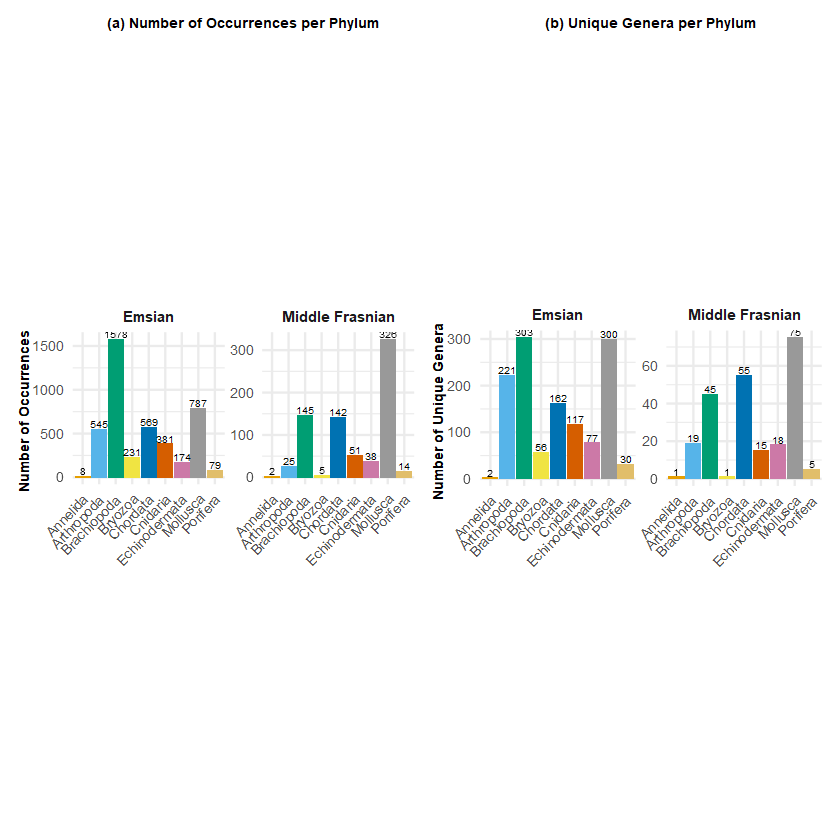

In [68]:
# Combine plots with panel labels

raw_occurences<- (stage_interval_occurrences + 
   ggtitle("(a) Number of Occurrences per Phylum"))+
(stage_interval_genus_occurrences + 
   ggtitle("(b) Unique Genera per Phylum"))

raw_occurences